In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from skimage import exposure, metrics
import seaborn as sns

# Set visual style
sns.set_theme(style="white")
%matplotlib inline

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from skimage import exposure


def load_volumes(path1, path2):
    vol1 = tiff.imread(path1)  # Shape: (50, H, W)
    vol2 = tiff.imread(path2)  # Shape: (24, H, W)

    # Normalize globally for comparison
    vol1_n = (vol1 - vol1.min()) / (vol1.max() - vol1.min())
    vol2_n = (vol2 - vol2.min()) / (vol2.max() - vol2.min())

    return vol1_n, vol2_n

path_a = '/home/student/sebastian_ma/VoronoiLoss/data/platelet-em/images/50-images.tif'
path_b = '/home/student/sebastian_ma/VoronoiLoss/data/platelet-em/images/24-images.tif'

vol_train, vol_val = load_volumes(path_a, path_b)

print(f"Train Volume Shape: {vol_train.shape}")
print(f"Test Volume Shape: {vol_val.shape}")

Train Volume Shape: (50, 800, 800)
Test Volume Shape: (24, 800, 800)


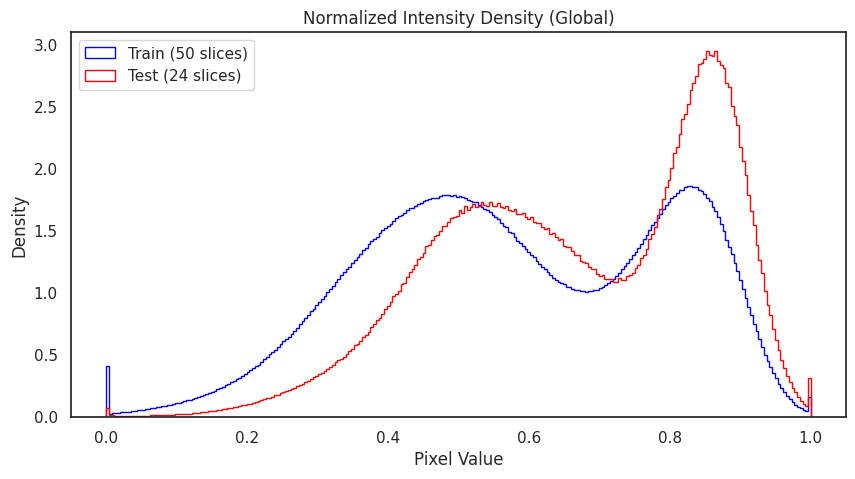

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(vol_train.ravel(), bins=256, histtype='step',
         label='Train (50 slices)', color='blue', density=True)
plt.hist(vol_val.ravel(), bins=256, histtype='step',
         label='Test (24 slices)', color='red', density=True)
plt.title("Normalized Intensity Density (Global)")
plt.xlabel("Pixel Value")
plt.ylabel("Density")
plt.legend()
plt.show()

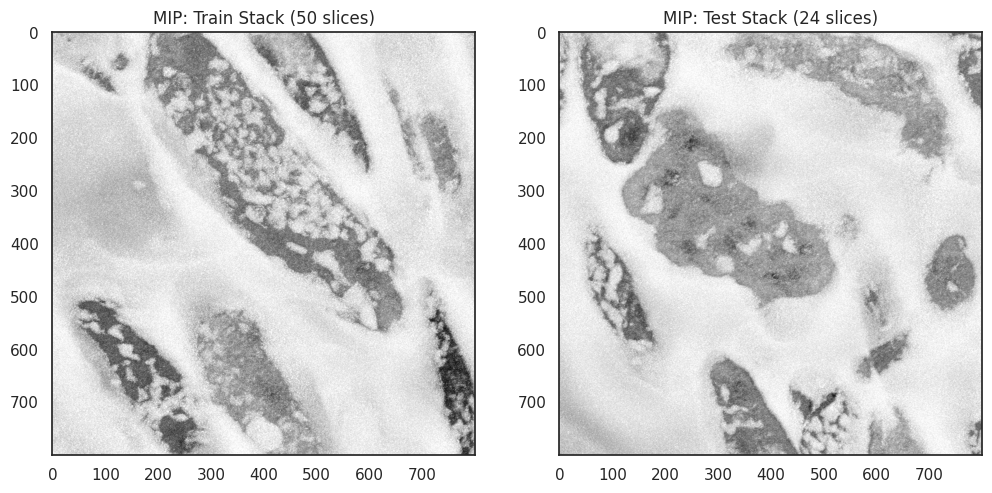

In [6]:
# Create Projections
mip_train = np.max(vol_train, axis=0)
mip_val = np.max(vol_val, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(mip_train, cmap='gray')
axes[0].set_title("MIP: Train Stack (50 slices)")

axes[1].imshow(mip_val, cmap='gray')
axes[1].set_title("MIP: Test Stack (24 slices)")

plt.show()

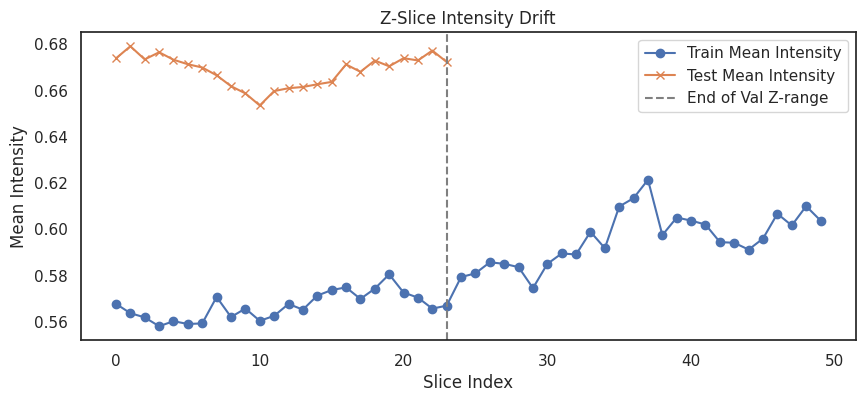

In [7]:
# Compare the mean intensity slice-by-slice
mean_train = [np.mean(s) for s in vol_train]
mean_val = [np.mean(s) for s in vol_val]

plt.figure(figsize=(10, 4))
plt.plot(mean_train, label='Train Mean Intensity', marker='o')
plt.plot(mean_val, label='Test Mean Intensity', marker='x')
plt.axvline(x=23, color='gray', linestyle='--', label='End of Val Z-range')
plt.title("Z-Slice Intensity Drift")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")
plt.legend()
plt.show()

In [44]:

from monai.transforms import (
    Compose,
    RandShiftIntensityd, RandGaussianSharpend,
    ScaleIntensityd,
    RandHistogramShiftd,
    EnsureChannelFirstd,
    RandBiasFieldd,
    NormalizeIntensityd,
    RandAdjustContrastd,ScaleIntensityRangePercentilesd,
    RandScaleIntensityd, RandGaussianSmoothd, RandGaussianNoised, Rand2DElasticd, HistogramNormalized
)

base_normalization = [
    EnsureChannelFirstd(keys=["image"], channel_dim="no_channel"),
    ScaleIntensityRangePercentilesd(
        keys=["image"],
        lower=1,
        upper=99,
        b_min=0.0,
        b_max=1.0,
        clip=True,
        channel_wise=False
    ),
]

# Define the augmentation pipeline
train_transforms = Compose([
    *base_normalization,
    Rand2DElasticd(
        keys=["image"],
        spacing=(48, 48),
        magnitude_range=(2, 5),
        prob=0.4,
        mode=["bilinear"],
        padding_mode="zeros",
    ),


    RandGaussianSmoothd(
        keys=["image"],
        sigma_x=(0.5, 1.0),
        sigma_y=(0.5, 1.0),
        prob=0.3
    ),
    RandAdjustContrastd(
        keys=['image'],
        gamma=(0.5, 1.5),
        invert_image=True,
        prob=0.3
    ),
    RandGaussianNoised(
        keys=["image"],
        mean=0.0,
        std=0.1,
        prob=0.3,
    ),

])
val_transforms = Compose([
    *base_normalization,
])

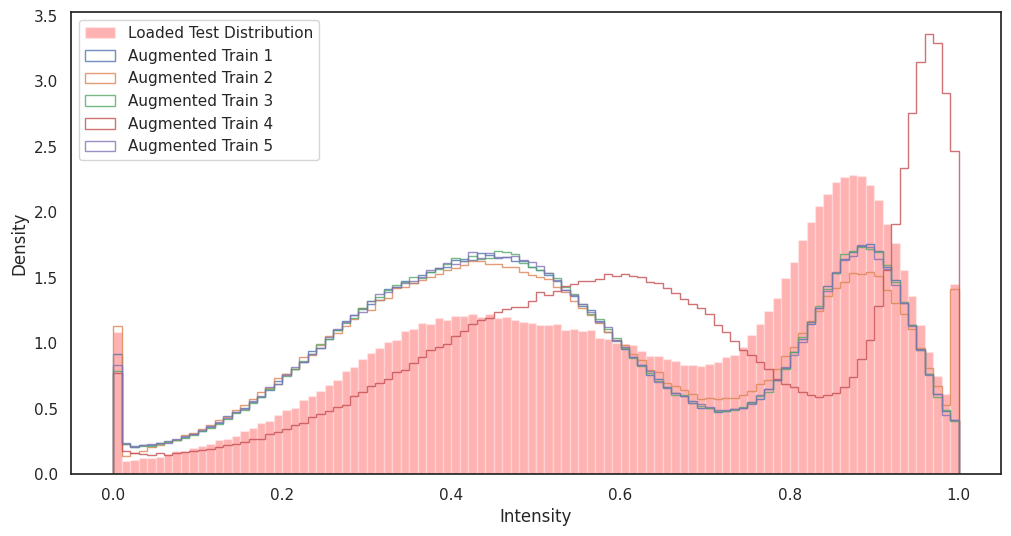

In [45]:
plt.figure(figsize=(12, 6))

SLICE = 1

# Convert your numpy slices to a format MONAI likes (dict)
train_data_dict = {"image": vol_train[SLICE]}  # Picking slice 0
test_data_dict = {"image": vol_val[SLICE]}  # Picking slice 0

plt.hist(val_transforms(test_data_dict)["image"].numpy().squeeze().ravel(), bins=100, alpha=0.3,
         label='Loaded Test Distribution', color='red', density=True)

# Apply augmentation 5 times to see the spread
for i in range(5):
    augmented_data = train_transforms(train_data_dict)
    aug_img = augmented_data["image"].numpy().squeeze()

    plt.hist(aug_img.ravel(), bins=100, histtype='step',
             alpha=0.8, label=f'Augmented Train {i+1}', density=True)

plt.xlabel("Intensity")
plt.ylabel("Density")
plt.legend()
plt.show()

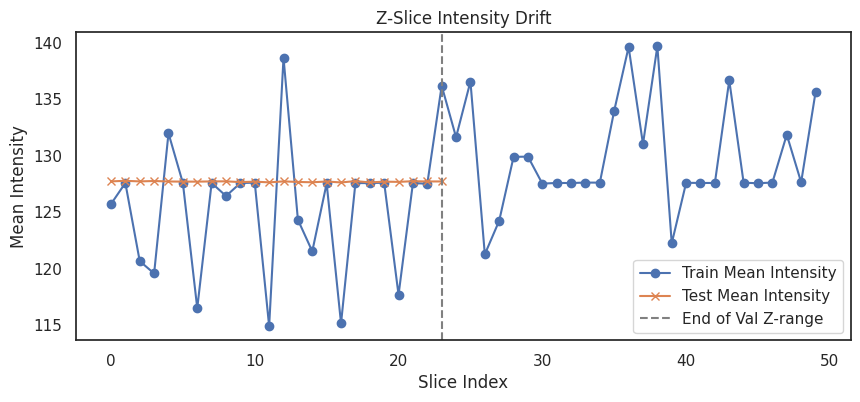

In [23]:
mean_train_aug = []
mean_test_aug = []

for image in vol_train:
    train_data_dict = {"image": image}
    augmented_data = train_transforms(train_data_dict)
    aug_img = augmented_data["image"].numpy().squeeze()
    mean_train_aug.append(np.mean(aug_img))
    

for image in vol_val:
    test_data_dict = {"image": image}
    augmented_data = val_transforms(test_data_dict)
    aug_img = augmented_data["image"].numpy().squeeze()
    aug_img = augmented_data["image"].numpy().squeeze()
    mean_test_aug.append(np.mean(aug_img))
    


plt.figure(figsize=(10, 4))
plt.plot(mean_train_aug, label='Train Mean Intensity', marker='o')
plt.plot(mean_test_aug, label='Test Mean Intensity', marker='x')
plt.axvline(x=23, color='gray', linestyle='--', label='End of Val Z-range')
plt.title("Z-Slice Intensity Drift")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")
plt.legend()
plt.show()

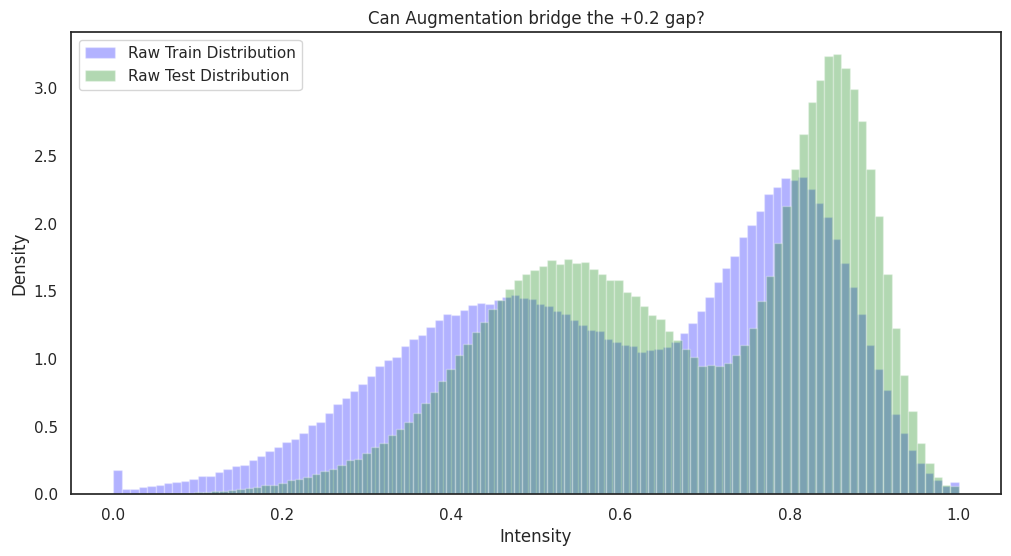

In [13]:
plt.figure(figsize=(12, 6))

# Plot the original Test distribution for reference

plt.hist(train_data_dict["image"].squeeze().ravel(), bins=100, alpha=0.3,
         label='Raw Train Distribution', color='blue', density=True)

plt.hist(test_data_dict["image"].squeeze().ravel(), bins=100, alpha=0.3,
         label='Raw Test Distribution', color='green', density=True)

plt.title("Can Augmentation bridge the +0.2 gap?")
plt.xlabel("Intensity")
plt.ylabel("Density")
plt.legend()
plt.show()

In [375]:
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import jensenshannon
import numpy as np


def quantify_distribution_gap(source_pixels, target_pixels):
    # Ensure they are flat and normalized
    source = source_pixels.ravel()
    target = target_pixels.ravel()

    # 1. Wasserstein Distance
    wd = wasserstein_distance(source, target)

    # 2. Jensen-Shannon (requires histograms of same bin count)
    hist_s, _ = np.histogram(source, bins=256, range=(0, 1), density=True)
    hist_t, _ = np.histogram(target, bins=256, range=(0, 1), density=True)
    jsd = jensenshannon(hist_s, hist_t)

    return {"Wasserstein": wd, "JS_Divergence": jsd}


# --- Usage ---
# Baseline: Before Augmentation
baseline_stats = quantify_distribution_gap(
    train_data_dict["image"].squeeze(), test_data_dict["image"].squeeze())

# Augmented: After applying your MONAI transforms
# (Assume 'aug_train_pixels' is the output of your transform pipeline)
aug_stats = quantify_distribution_gap(train_transforms(train_data_dict)["image"].numpy().squeeze(), val_transforms(
    test_data_dict)["image"].numpy().squeeze())

print(f"Baseline Gap: {baseline_stats}")
print(f"Augmented Gap: {aug_stats}")

Baseline Gap: {'Wasserstein': np.float64(0.9148371157979182), 'JS_Divergence': np.float64(0.4270532685135661)}
Augmented Gap: {'Wasserstein': np.float64(0.1749909888505112), 'JS_Divergence': np.float64(0.24844560423282516)}


In [46]:
data = [
    {"image": "/home/student/sebastian_ma/VoronoiLoss/data/platelet-em/images/50-images.tif",
        "label": "/home/student/sebastian_ma/VoronoiLoss/data/platelet-em/labels-semantic/50-semantic.tif"},
    {"image": "/home/student/sebastian_ma/VoronoiLoss/data/platelet-em/images/24-images.tif",
        "label": "/home/student/sebastian_ma/VoronoiLoss/data/platelet-em/labels-semantic/24-semantic.tif"},
]

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    ScaleIntensityRanged, MapTransform, RandSpatialCropd
)
from monai.data import Dataset, DataLoader

SEMANTIC_COLORS = np.array([
    [0,   0,   0,   0],        # 0: Background
    [0,  40, 255, 255],        # 1: Cell
    [0, 212, 255, 255],        # 2: Mitochondrion
    [124, 255, 121, 255],     # 3: Alpha granule
    [255, 229,   0, 255],     # 4: Canalicular vessel
    [255,  70,   0, 255],     # 5: Dense granule body
    [127,   0,  127, 255],    # 6: Dense granule core
], dtype=np.uint8)


class SemanticColorToBinaryd(MapTransform):
    def __init__(self, keys, target_class):
        super().__init__(keys)
        self.semantic_colors = SEMANTIC_COLORS
        self.target_color = SEMANTIC_COLORS[target_class]
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = d[key] # shape: (4, H, W) or (H, W, 4)
            if label.shape[0] == 4:
                label = np.moveaxis(label, 0, -1)
                binary = np.all(label == self.target_color, axis=-1)
                d[key] = binary[None].astype(np.float32)
        return d

# 2. Define the Pipeline
# Note: I removed SplitDimd. To get 2D slices from 3D TIFs,
# we crop with depth=1 and then squeeze the Z dimension.
test_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityRangePercentilesd(
        keys=["image"],
        lower=1,
        upper=99,
        b_min=0.0,
        b_max=1.0,
        clip=True,
        channel_wise=False
    ),
    SemanticColorToBinaryd(
        keys=["label"],
        target_class=3,
    ),
    RandSpatialCropd(
        keys=["image", "label"],
        roi_size=(256, 256, 1),  # Crop a 2D slice from the 3D stack
        random_size=False,
    ),
])

[  0. 124. 127. 255.]


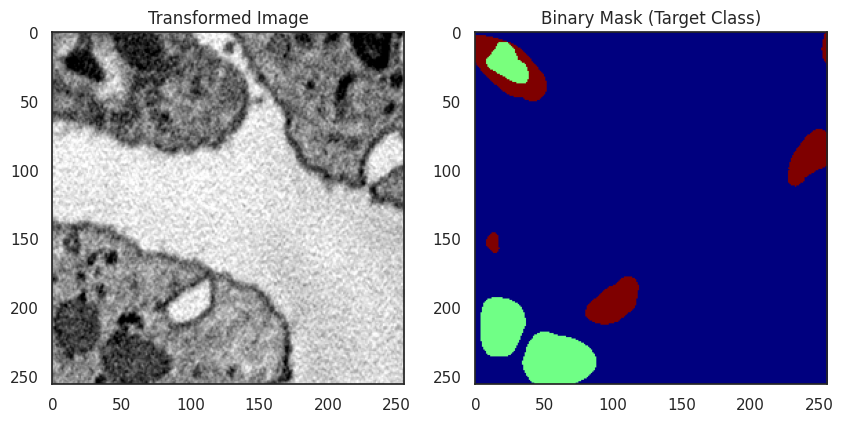

Image shape: torch.Size([1, 1, 256, 256, 1])
Label range: 0.0 to 255.0


In [74]:
check_ds = Dataset(data=data, transform=test_transforms)
check_loader = DataLoader(check_ds, batch_size=1)

def check_pipeline():
    try:
        batch = next(iter(check_loader))
        img = batch["image"][0, 0, :, :, 0]  # Take first channel, first slice
        seg = batch["label"][0, 0, :, :, 0]
        print(np.unique(seg))
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title("Transformed Image")
        plt.imshow(img, cmap="gray")
        plt.subplot(1, 2, 2)
        plt.title("Binary Mask (Target Class)")
        plt.imshow(seg, cmap="jet")
        plt.show()

        # Should be (1, 1, 256, 256, 1)
        print(f"Image shape: {batch['image'].shape}")
        print(f"Label range: {seg.min()} to {seg.max()}")

    except Exception as e:
        print(f"Pipeline failed: {e}")


check_pipeline()